In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Student_performance_data.csv')

In [3]:
df.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [5]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


<Axes: xlabel='GPA', ylabel='Count'>

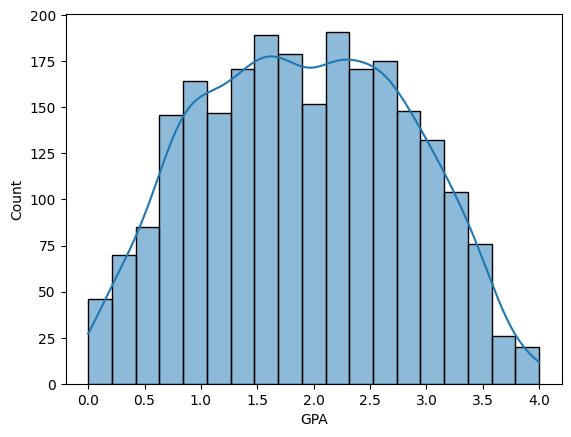

In [6]:
sns.histplot(df['GPA'],kde=True)

<Axes: ylabel='GPA'>

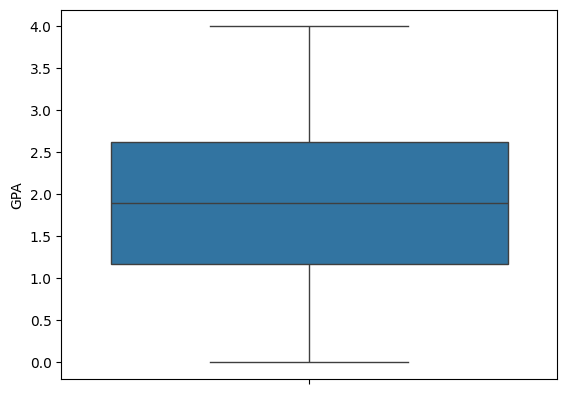

In [7]:
sns.boxplot(df['GPA'])

<Axes: >

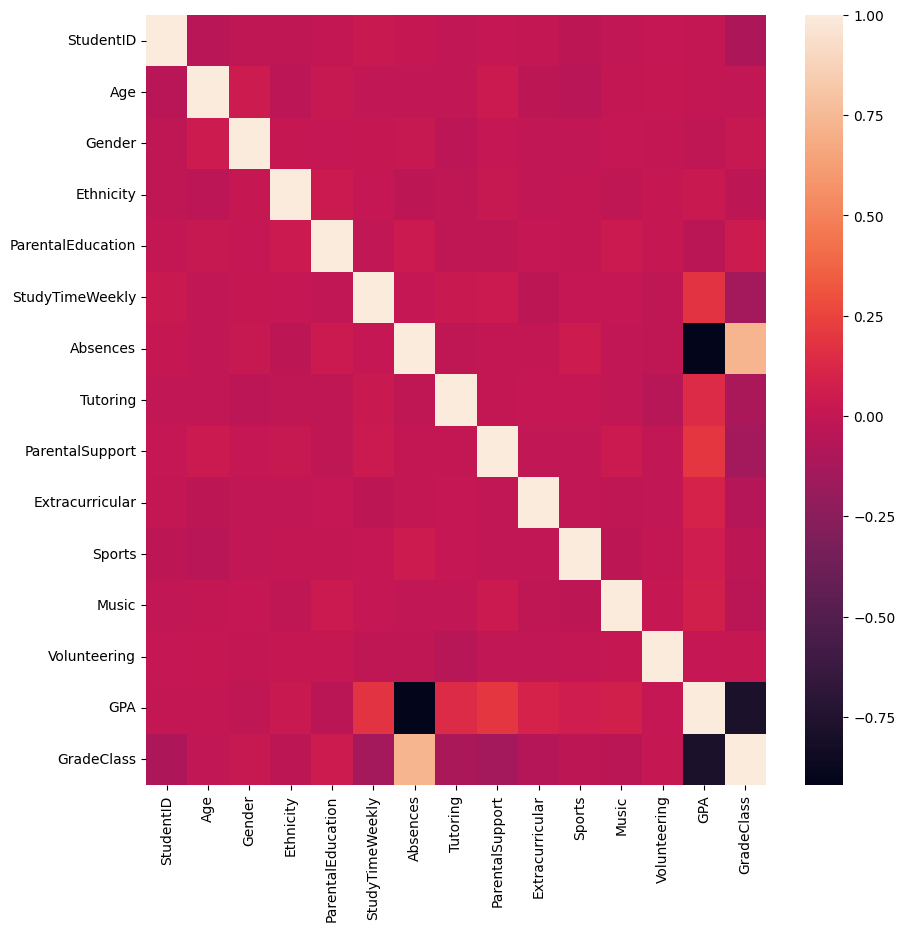

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr())

In [9]:
#Dependent and Independent variables seperate
#Train,Test and Split
#Standard Scaler
#Training and Testing

In [10]:
x=df.drop(['StudentID','GPA'],axis=1)
y=df['GPA']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [13]:
df.shape

(2392, 15)

In [14]:
from sklearn.preprocessing import StandardScaler
se=StandardScaler()
X_train=se.fit_transform(x_train)
X_test=se.fit_transform(x_test)

In [15]:
from sklearn.neighbors import KNeighborsRegressor
model=KNeighborsRegressor(n_neighbors=10)

In [16]:
#Train data
model.fit(X_train,y_train)



KNeighborsRegressor(n_neighbors=10)

In [17]:
#Predict data
y_pred=model.predict(X_test)

In [18]:
#evaluate model
from sklearn.metrics import r2_score


In [19]:
#evaluate on testing data
r2_score(y_test,y_pred)

0.8195709592827158

In [20]:
#Evaluate on training data
y_pred_train=model.predict(X_train)
r2_score(y_train,y_pred_train)

0.8539354150936007

In [21]:
r2=[]
for i in range(1,16):
  knn_model = KNeighborsRegressor(n_neighbors=i)
  knn_model.fit(X_train,y_train)
  y_pred = knn_model.predict(X_test)
  accuracy = r2_score(y_test,y_pred)
  r2.append(accuracy)
print(r2)

[0.6693829078912581, 0.7628049116171693, 0.7866328969602079, 0.8027387505030043, 0.8050407881377399, 0.8107891609367369, 0.8124640704148806, 0.8138729547402588, 0.8137654799951861, 0.8195709592827158, 0.8219934465533127, 0.8203136323941783, 0.818035564341834, 0.8175737536302844, 0.8196454345146531]


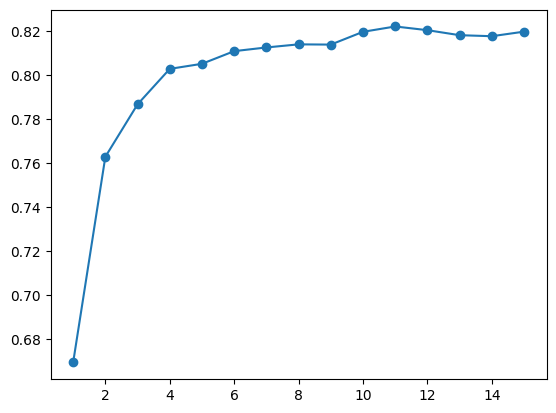

In [22]:
plt.plot(range(1,16),r2,marker='o')

In [23]:
df['GradeClass'].value_counts()

,count
GradeClass,
4.0,1211
3.0,414
2.0,391
1.0,269
0.0,107


In [24]:
#splitting X and Y for Navie Bayes model
#traingin on naice bayes model

X= df.drop(['StudentID','GradeClass'],axis=1)
y=df['GradeClass']

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [27]:
from sklearn.naive_bayes import GaussianNB

In [28]:
model=GaussianNB()

In [29]:
#train on data(fit)
#predict(pred)
#evaluate

In [30]:
#train
model.fit(X_train,y_train)

GaussianNB()

In [31]:
y_pred=model.predict(X_test)

In [32]:
#evaluation
from sklearn.metrics import classification_report,accuracy_score
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.25      0.06      0.10        33
         1.0       0.61      0.54      0.57        80
         2.0       0.63      0.80      0.71       121
         3.0       0.62      0.69      0.65       127
         4.0       0.93      0.90      0.92       357

    accuracy                           0.77       718
   macro avg       0.61      0.60      0.59       718
weighted avg       0.76      0.77      0.76       718

0.7674094707520891


In [33]:
y_pred_train=model.predict(X_train)
print(classification_report(y_train,y_pred_train))
print(accuracy_score(y_train,y_pred_train))

              precision    recall  f1-score   support

         0.0       0.68      0.18      0.28        74
         1.0       0.68      0.61      0.64       189
         2.0       0.68      0.82      0.75       270
         3.0       0.63      0.74      0.68       287
         4.0       0.92      0.89      0.91       854

    accuracy                           0.79      1674
   macro avg       0.72      0.65      0.65      1674
weighted avg       0.80      0.79      0.79      1674

0.7921146953405018


In [35]:
import joblib
joblib.dump(model,'gaussian.pkl')
joblib.dump(se,'scaler_.pkl')

['scaler_.pkl']